In [728]:
# Install the libraries used in this project.
%pip install matplotlib seaborn pandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [729]:
# Import libraries for data analysis and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [730]:
# Check the current working directory.
os.getcwd()

'/Users/alitokgoz/PycharmProjects/Titanic-data-science/notebooks'

# 1.Data Understanding & Initial EDA

In [731]:
# Load the Titanic training dataset.
df=pd.read_csv('/Users/alitokgoz/PycharmProjects/Titanic-data-science/data/train.csv')

In [732]:
# Preview the first five rows of the dataset.
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [733]:
# Check the number of rows and columns.
df.shape

(891, 12)

In [734]:
# Inspect column data types and non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [735]:
# Count missing values in each column.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [736]:
# Calculate survival counts and percentages.
df["Survived"].value_counts()
(df["Survived"].value_counts(normalize=True)*100).round(2) # Percentage

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

In [737]:
# Summarize age statistics rounded to two decimal places.
df["Age"].describe().round(2)

count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: Age, dtype: float64

In [738]:
# Inspect unique values and their counts in categorical columns.
print("Sex:", df["Sex"].nunique(), df["Sex"].unique())
print("Pclass:", df["Pclass"].nunique(), df["Pclass"].unique())
print("Embarked:", df["Embarked"].nunique(), df["Embarked"].unique())

Sex: 2 <StringArray>
['male', 'female']
Length: 2, dtype: str
Pclass: 3 [3 1 2]
Embarked: 3 <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [739]:
# Calculate survival percentages by sex, rounding proportions first.
df.groupby("Sex")["Survived"].mean().round(2)*100   

Sex
female    74.0
male      19.0
Name: Survived, dtype: float64

# 2. Exploration Data Analysis 

In [740]:
# Count duplicate rows in the dataset.
df.duplicated().sum()

np.int64(0)

In [741]:
# Calculate survival percentages, rounding proportions first.
df["Survived"].value_counts(normalize=True).round(2)*100


Survived
0    62.0
1    38.0
Name: proportion, dtype: float64

In [742]:
# Calculate survival rates by sex.
(df.groupby("Sex")["Survived"].mean()*100).round(2)

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

In [743]:
# Calculate survival rates by passenger class.
(df.groupby("Pclass")["Survived"].mean()*100).round(2)

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

In [744]:
# Summarize the age distribution.
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

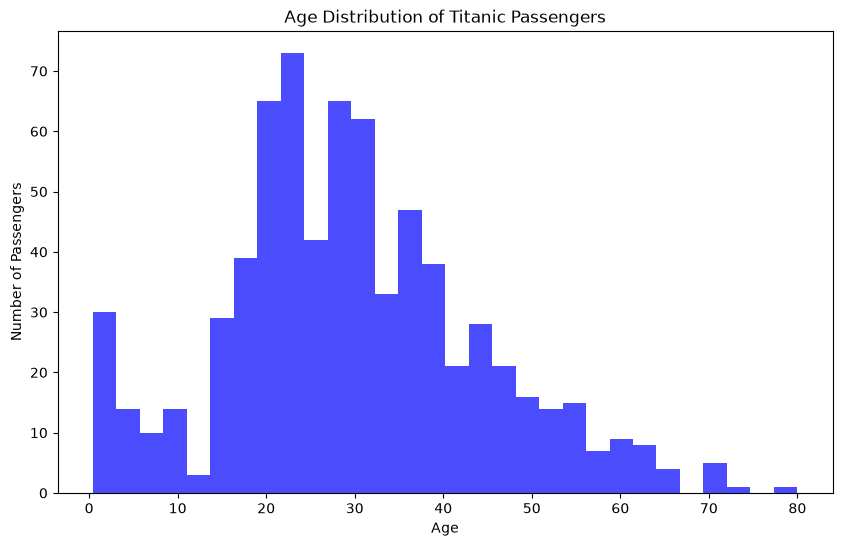

In [745]:
# Visualize the age distribution.
plt.figure(figsize=(10,6))
plt.hist(df["Age"].dropna(),bins=30, color='blue', alpha=0.7)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


Text(0, 0.5, 'Number of Passengers')

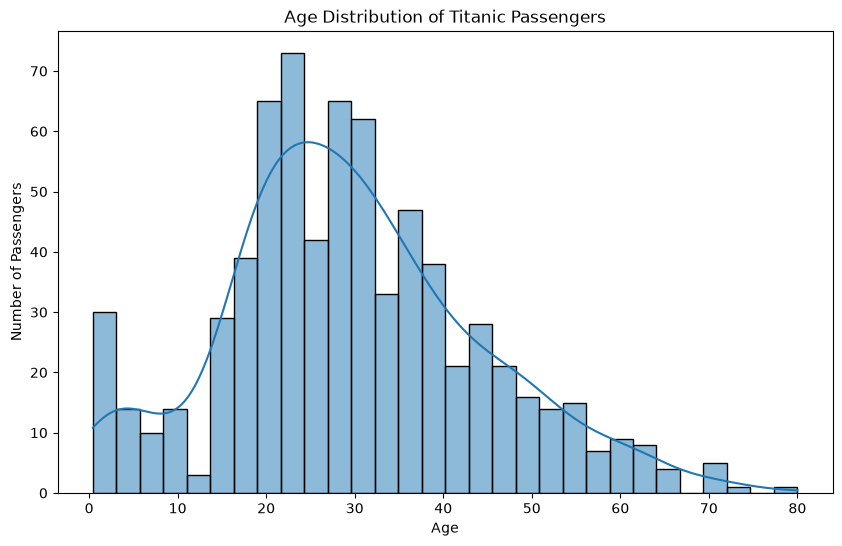

In [746]:
# Visualize the age distribution.
plt.figure(figsize=(10, 6))
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")      

In [747]:
# Summarize the fare distribution.
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

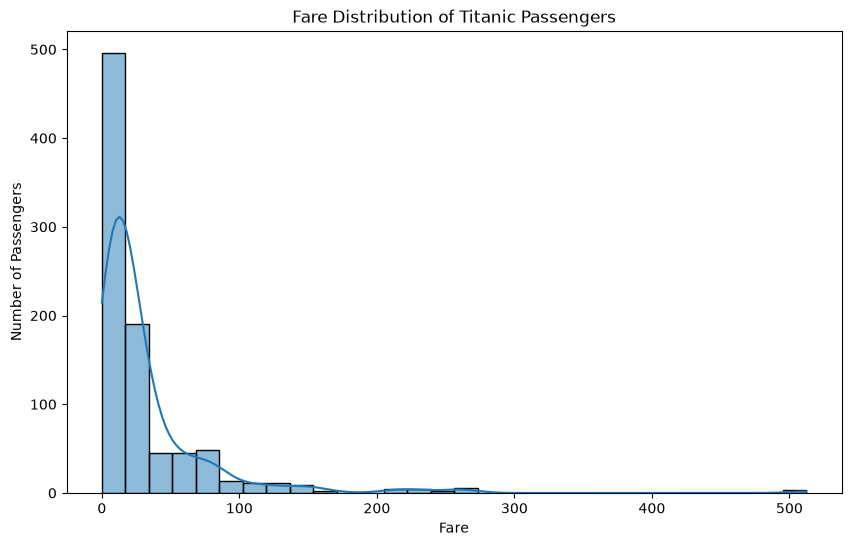

In [748]:
# Visualize the fare distribution.
plt.figure(figsize=(10, 6))
sns.histplot(df["Fare"].dropna(),bins=30, kde=True)
plt.title("Fare Distribution of Titanic Passengers")    
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")  
plt.show()

In [749]:
# Calculate survival rates by embarkation port.
df.groupby("Embarked")["Survived"].mean().round(2)*100

Embarked
C    55.0
Q    39.0
S    34.0
Name: Survived, dtype: float64

In [750]:
# Calculate survival rates by sex and passenger class.
df.groupby(["Sex","Pclass"])["Survived"].mean().round(2)*100

Sex     Pclass
female  1         97.0
        2         92.0
        3         50.0
male    1         37.0
        2         16.0
        3         14.0
Name: Survived, dtype: float64

# 3. Data Cleaning & Feature Engineering

In [751]:
# Calculate the percentage of missing values in each column.
missing_values = df.isnull().sum()
missing_values[missing_values > 0] 

Age         177
Cabin       687
Embarked      2
dtype: int64

#### Missing Value Strategy

- **Age:** Fill missing values using the median age of passengers with the same title (e.g., Mr, Mrs, Miss, Master), extracted from the `Name` column.
- **Embarked:** Fill the 2 missing values with the most frequent embarkation port (mode), since only a very small proportion of values are missing.
- **Cabin:** Do not impute cabin numbers because approximately 77% of the values are missing. Instead, create a new feature indicating whether cabin information is available.

In [752]:
# Extract passenger titles from the Name column and inspect age patterns.
def extract_title(name):
    return name.split(",")[1].split(".")[0].strip()
df["Title"]=df["Name"].apply(extract_title)
df["Title"].value_counts()
df.groupby("Title")["Age"].median().round(2)

Title
Capt            70.0
Col             58.0
Don             40.0
Dr              46.5
Jonkheer        38.0
Lady            48.0
Major           48.5
Master           3.5
Miss            21.0
Mlle            24.0
Mme             24.0
Mr              30.0
Mrs             35.0
Ms              28.0
Rev             46.5
Sir             49.0
the Countess    33.0
Name: Age, dtype: float64

In [753]:
# Count passengers in each title group.
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [754]:
# Standardize equivalent titles and group uncommon titles as Rare.
df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})
rare_titles = [
    "Dr", "Rev", "Major", "Col", "Don",
    "Lady", "Sir", "Capt", "the Countess", "Jonkheer"
]

df.loc[df["Title"].isin(rare_titles), "Title"] = "Rare"
df.groupby("Title")["Age"].median().round(2)

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

In [755]:
# Fill missing Age values with the median age of each title group.
title_medianages= df.groupby("Title")["Age"].transform("median")
df["Age"]=df["Age"].fillna(title_medianages)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [756]:
# Fill missing Embarked values with the most frequent port.
df["Embarked"].value_counts()
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"].isnull().sum()

np.int64(0)

In [757]:
# Create a binary feature indicating whether cabin information is available.
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["HasCabin"].value_counts()


HasCabin
0    687
1    204
Name: count, dtype: int64

In [758]:
# Create a feature representing the passenger's total family size.
df["FamilySize"]=df["SibSp"]+df["Parch"]+1  
df["FamilySize"].value_counts().sort_index(ascending=False)


FamilySize
11      7
8       6
7      12
6      22
5      15
4      29
3     102
2     161
1     537
Name: count, dtype: int64

In [759]:
# Create a binary feature indicating whether the passenger traveled alone.
def is_alone(family_size):
    return 1 if family_size == 1 else 0 
df["IsAlone"] = df["FamilySize"].apply(is_alone)
df["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

In [760]:
# Compare survival rates by family size and solo travel status.
print("Survival rates by Family Size:")
print((df.groupby("FamilySize")["Survived"].mean().round(2)*100).sort_index(ascending=True))
print("\nSurvival rates by IsAlone:")
print((df.groupby("IsAlone")["Survived"].mean().round(2)*100).sort_index(ascending=True))    

Survival rates by Family Size:
FamilySize
1     30.0
2     55.0
3     58.0
4     72.0
5     20.0
6     14.0
7     33.0
8      0.0
11     0.0
Name: Survived, dtype: float64

Survival rates by IsAlone:
IsAlone
0    51.0
1    30.0
Name: Survived, dtype: float64


In [761]:
# Calculate the estimated fare paid per family member.
df["FareperPerson"]=df["Fare"]/df["FamilySize"]
df["FareperPerson"].describe().round(2) 

count    891.00
mean      19.92
std       35.84
min        0.00
25%        7.25
50%        8.30
75%       23.67
max      512.33
Name: FareperPerson, dtype: float64

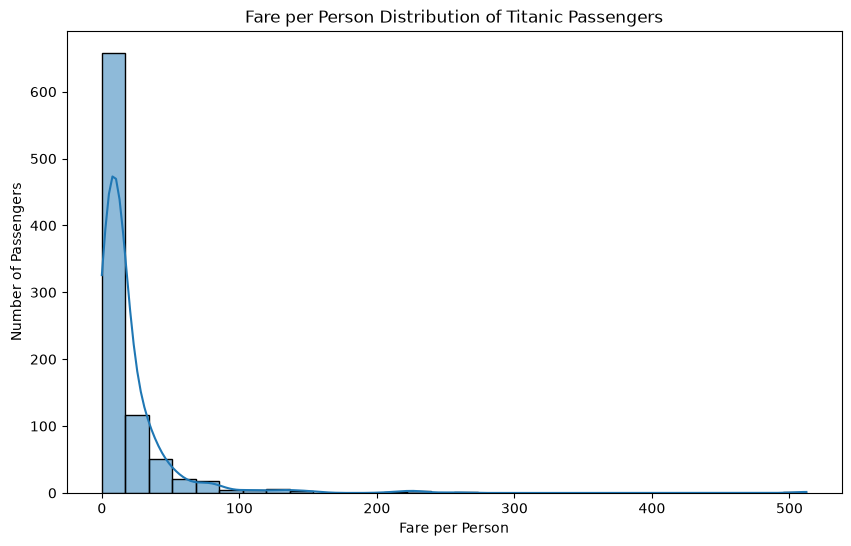

In [762]:
plt.figure(figsize=(10, 6))
sns.histplot(df["FareperPerson"].dropna(), bins=30, kde=True)
plt.title("Fare per Person Distribution of Titanic Passengers")
plt.xlabel("Fare per Person")
plt.ylabel("Number of Passengers")
plt.show()

In [763]:
# Review the dataset after cleaning and feature engineering.
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (891, 17)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'HasCabin', 'FamilySize', 'IsAlone', 'FareperPerson']

Data types:
PassengerId        int64
Survived           int64
Pclass             int64
Name                 str
Sex                  str
Age              float64
SibSp              int64
Parch              int64
Ticket               str
Fare             float64
Cabin                str
Embarked             str
Title                str
HasCabin           int64
FamilySize         int64
IsAlone            int64
FareperPerson    float64
dtype: object

Missing values:
PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           0
Title              0
HasCabin           0
FamilySize         0
I

# 4. Data Preparation for Machine Learning

### Feature Review

- **Target:** `Survived` is the variable the model will predict.
- **Engineered features:** `Title`, `HasCabin`, `FamilySize`, `IsAlone`, and `FareperPerson`.
- **Potential columns to remove before modeling:** `PassengerId`, `Name`, `Ticket`, and `Cabin`.
- `Cabin` is the only column that still contains missing values; its useful availability information is represented by `HasCabin`.
- Categorical features such as `Sex`, `Embarked`, and `Title` must be encoded before model training.

In [764]:
y= df["Survived"]
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])  # Drop irrelevant columns

### Excluded Features

- **PassengerId:** A unique identifier with no direct passenger characteristic.
- **Name:** High-cardinality text; useful title information has already been extracted.
- **Ticket:** High-cardinality text that requires additional feature engineering.
- **Cabin:** Contains many missing values; cabin availability is represented by `HasCabin`.

In [765]:
# Review the features selected for the initial model.
feature_columns = X.columns.tolist()
X=df[feature_columns].copy()
X.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pclass         891 non-null    int64  
 1   Sex            891 non-null    str    
 2   Age            891 non-null    float64
 3   SibSp          891 non-null    int64  
 4   Parch          891 non-null    int64  
 5   Fare           891 non-null    float64
 6   Embarked       891 non-null    str    
 7   Title          891 non-null    str    
 8   HasCabin       891 non-null    int64  
 9   FamilySize     891 non-null    int64  
 10  IsAlone        891 non-null    int64  
 11  FareperPerson  891 non-null    float64
dtypes: float64(3), int64(6), str(3)
memory usage: 83.7 KB


In [766]:
# Separate categorical and numerical features for preprocessing.
categorical_features = ["Sex","Embarked","Title",]
numerical_features = ["Age","Fare","FamilySize","IsAlone","FareperPerson","Pclass","HasCabin","SibSp","Parch"]

In [767]:
def map_sex(sex):
    if sex =="male":
        return 1
    elif sex=="female":
        return 0
    else:
        raise ValueError(f"Unexpected value for sex: {sex}")

X["Sex"] = X["Sex"].apply(map_sex)
X["Sex"].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

In [768]:
# One-hot encode the Embarked feature.
X=pd.get_dummies(
    X,                       # hangi dataframe?
    columns=["Embarked"],    # hangi sütunu dönüştüreceğim?
    dtype=int                # sonuçlar 0/1 integer olsun
)


In [769]:
X.filter(like="Embarked").head(10)  # Display the first 10 rows of the one-hot encoded Embarked columns

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
5,0,1,0
6,0,0,1
7,0,0,1
8,0,0,1
9,1,0,0


In [770]:
# One-hot encode the Title feature. 
X= pd.get_dummies(
        X,
        columns=["Title"],
        dtype=int  
 )
X.filter(like="Title").head(10)  # Display the first 10 rows of the one-hot encoded Title columns

,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,0,1,0,0
1,0,0,0,1,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,1,0,0
5,0,0,1,0,0
6,0,0,1,0,0
7,1,0,0,0,0
8,0,0,0,1,0
9,0,0,0,1,0


In [771]:
# Verify that all model features have numerical data types.
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pclass         891 non-null    int64  
 1   Sex            891 non-null    int64  
 2   Age            891 non-null    float64
 3   SibSp          891 non-null    int64  
 4   Parch          891 non-null    int64  
 5   Fare           891 non-null    float64
 6   HasCabin       891 non-null    int64  
 7   FamilySize     891 non-null    int64  
 8   IsAlone        891 non-null    int64  
 9   FareperPerson  891 non-null    float64
 10  Embarked_C     891 non-null    int64  
 11  Embarked_Q     891 non-null    int64  
 12  Embarked_S     891 non-null    int64  
 13  Title_Master   891 non-null    int64  
 14  Title_Miss     891 non-null    int64  
 15  Title_Mr       891 non-null    int64  
 16  Title_Mrs      891 non-null    int64  
 17  Title_Rare     891 non-null    int64  
dtypes: float64(3), int64(

In [772]:
X.isnull().sum()  

Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
HasCabin         0
FamilySize       0
IsAlone          0
FareperPerson    0
Embarked_C       0
Embarked_Q       0
Embarked_S       0
Title_Master     0
Title_Miss       0
Title_Mr         0
Title_Mrs        0
Title_Rare       0
dtype: int64

In [773]:
print("X.shape():", X.shape)
print("y.shape():", y.shape)
print("Index equality:",X.index.equals(y.index))

X.shape(): (891, 18)
y.shape(): (891,)
Index equality: True


# 5. Train/Validation Split and Model Training 

In [774]:
from sklearn.model_selection import train_test_split

In [775]:
# Split the data into training and validation sets.

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [776]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((712, 18), (179, 18), (712,), (179,))

In [777]:
from sklearn.linear_model import LogisticRegression

In [778]:
model = LogisticRegression(max_iter=1000)

In [779]:
# Train the model
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [780]:
# Make predictions on the validation set.
y_pred=model.predict(X_val)

In [781]:
y_pred[:10]

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0])

In [782]:
#With validation set predictions
comparison=pd.DataFrame({"Actual":y_val,"Predicted":y_pred})
comparison.head(10)  # Display the first 10 rows of the comparison DataFrame

,Actual,Predicted
565,0,0
160,0,0
553,1,0
860,0,0
241,1,1
559,1,1
387,1,1
536,0,1
698,0,0
99,0,0


In [783]:
from sklearn.metrics import accuracy_score

In [784]:
#Calculate the accuracy of the model on the validation set.
val_accuracy=round(accuracy_score(y_val,y_pred), 4)

In [785]:
y_train_pred = model.predict(X_train)
y_train_pred[:10]   

array([0, 0, 1, 1, 1, 0, 0, 0, 0, 1])

In [786]:
#With training set predictions
comparison_train=pd.DataFrame({"Actual":y_train,"Predicted":y_train_pred})  
print(comparison_train.head(10))  # Display the first 10 rows of the training set comparison DataFrame  

     Actual  Predicted
692       1          0
481       0          0
527       0          1
855       1          1
801       1          1
652       0          0
509       1          0
557       0          0
828       1          0
18        0          1


In [787]:
#Calculate the accuracy of the model on the training set.
train_accuracy=round(accuracy_score(y_train,y_train_pred),4)
print(train_accuracy)

0.8385


In [788]:
# Import classification metrics for detailed model evaluation.
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Calculate the validation precision,recall,f1 score.
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)

print(val_precision)
print(val_recall)
print(val_f1)

0.8059701492537313
0.782608695652174
0.7941176470588235


In [ ]:
#Confusion matrix for the validation set predictions.    
cm = confusion_matrix(y_val, y_pred)    
print(cm)

[[97 13]
 [15 54]]


In [791]:
from sklearn.metrics import classification_report

In [792]:
report = classification_report(y_val, y_pred)   
print(report)

              precision    recall  f1-score   support

           0       0.87      0.88      0.87       110
           1       0.81      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



# 6.   5-Fold Cross Validation

In [793]:
from sklearn.model_selection import cross_val_score

In [796]:
cv_score = cross_val_score(model,X,y,cv=5,scoring="accuracy")
print("Cross-validation scores:", cv_score) 

Cross-validation scores: [0.82681564 0.80898876 0.79775281 0.82022472 0.87640449]


In [799]:
cv_mean = cv_score.mean()
cv_std = cv_score.std()
print("Mean cross-validation score:", cv_mean)  
print("Standard deviation of cross-validation scores:", cv_std)  

Mean cross-validation score: 0.8260372857949909
Standard deviation of cross-validation scores: 0.027062561569737


# 7.Logistic Regression Coefficients / Feature Importance

In [800]:
print(model.coef_)

[[-7.51324316e-01 -1.22437614e+00 -3.44688722e-02 -2.14863814e-01
  -6.40100691e-02  1.45925559e-03  8.72214666e-01 -2.82254054e-01
  -3.17174256e-01  1.28082286e-03  1.83420818e-02  2.74703184e-01
  -2.96425437e-01  1.05268554e+00  1.94524275e-02 -1.39910311e+00
   8.14569045e-01 -4.90984074e-01]]


In [806]:
coefficient_df =pd.DataFrame({
       "Feature":X.columns,
       "Coefficient":model.coef_[0] 
    })
print(coefficient_df.sort_values(by="Coefficient", ascending=False))

          Feature  Coefficient
13   Title_Master     1.052686
6        HasCabin     0.872215
16      Title_Mrs     0.814569
11     Embarked_Q     0.274703
14     Title_Miss     0.019452
10     Embarked_C     0.018342
5            Fare     0.001459
9   FareperPerson     0.001281
2             Age    -0.034469
4           Parch    -0.064010
3           SibSp    -0.214864
7      FamilySize    -0.282254
12     Embarked_S    -0.296425
8         IsAlone    -0.317174
17     Title_Rare    -0.490984
0          Pclass    -0.751324
1             Sex    -1.224376
15       Title_Mr    -1.399103


# 8. Decision Tree

In [807]:
from sklearn.tree import DecisionTreeClassifier

In [809]:
dt_model  = DecisionTreeClassifier()
print(dt_model)

DecisionTreeClassifier()


In [810]:
dt_model.fit(X_train, y_train)          

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [813]:
dt_pred = dt_model.predict(X_val)
dt_accuracy = round(accuracy_score(y_val, dt_pred), 4)
print("Decision Tree Validation Accuracy:", dt_accuracy)

Decision Tree Validation Accuracy: 0.7877


In [814]:
dt_train_pred = dt_model.predict(X_train)
dt_train_accuracy = round(accuracy_score(y_train, dt_train_pred), 4)
print("Decision Tree Training Accuracy:", dt_train_accuracy)

Decision Tree Training Accuracy: 0.9874


# 9.Random Forest

In [815]:
from sklearn.ensemble import RandomForestClassifier

In [816]:
rf_model =RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [817]:
rf_pred= rf_model.predict(X_val)
rf_accuracy = round(accuracy_score(y_val, rf_pred), 4)
print("Random Forest Validation Accuracy:", rf_accuracy)

Random Forest Validation Accuracy: 0.7877


In [818]:
rf_train_pred = rf_model.predict(X_train)
rf_train_accuracy = round(accuracy_score(y_train, rf_train_pred), 4)
print("Random Forest Training Accuracy:", rf_train_accuracy)

Random Forest Training Accuracy: 0.9874


In [819]:
#Model Comparison
model_comparispon_df= pd.DataFrame({
        "Model":["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier"],
        "Validation Accuracy":[val_accuracy,dt_accuracy,rf_accuracy],
        "Training Accuracy":[train_accuracy,dt_train_accuracy,rf_train_accuracy]        
})
print(model_comparispon_df)

                    Model  Validation Accuracy  Training Accuracy
0      LogisticRegression               0.8436             0.8385
1  DecisionTreeClassifier               0.7877             0.9874
2  RandomForestClassifier               0.7877             0.9874


# 10.Hyperparameter Tuning

In [820]:
from sklearn.model_selection import GridSearchCV

In [821]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

In [822]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

In [823]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

In [824]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.8315


In [826]:
best_rf_model = grid_search.best_estimator_
tuned_rf_pred = best_rf_model.predict(X_val)
tuned_rf_accuracy = round(accuracy_score(y_val, tuned_rf_pred), 4)
print("Tuned Random Forest Validation Accuracy:", tuned_rf_accuracy)

Tuned Random Forest Validation Accuracy: 0.8101


In [827]:
tuned_rf_train_pred = best_rf_model.predict(X_train)
tuned_rf_train_accuracy = round(accuracy_score(y_train, tuned_rf_train_pred), 4)
print("Tuned Random Forest Training Accuracy:", tuned_rf_train_accuracy)

Tuned Random Forest Training Accuracy: 0.9256


## ROC Curve and ROC-AUC Evaluation